# **Imports**

In [ ]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 32.7 MB/s 
     |████████████████████████████████| 9.5 MB 39.3 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-aqv1aiak
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-aqv1aiak
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997353 sha256=04801019a0b162fe69069fc4649983523c14aa5f2b4e1590af391549b43d7294
  Stored in directory: /tmp/pip-ephem-wheel-cache-3cn0xuuy/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [ ]:
!gdown --id 1qwjI066stPdfyQxHyrmFNU6R1h3SS2h8

Downloading...
From: https://drive.google.com/uc?id=1qwjI066stPdfyQxHyrmFNU6R1h3SS2h8
To: /content/HDFCBANK.NS.csv
100% 155k/155k [00:00<00:00, 4.98MB/s]


In [ ]:
stock_name="HDFCBANK"

In [ ]:
df_stock = pd.read_csv('HDFCBANK.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,541.200012,545.125000,538.075012,544.375000,1597538.0,4,1,1,7791.299805,7.049988
2016-01-04,542.000000,542.000000,534.049988,535.250000,2593768.0,0,4,1,7784.649902,7.950012
2016-01-05,535.099976,537.400024,530.674988,531.200012,1580436.0,1,5,1,7741.000000,6.725037
2016-01-06,528.325012,538.375000,528.325012,533.549988,2082768.0,2,6,1,7568.299805,10.049988
2016-01-07,530.049988,532.450012,524.849976,528.099976,3027714.0,3,7,1,7601.350098,7.600037


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [ ]:
df_stock['Close'].head()

Date
2016-01-01    544.375000
2016-01-04    535.250000
2016-01-05    531.200012
2016-01-06    533.549988
2016-01-07    528.099976
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - HDFCBANK')

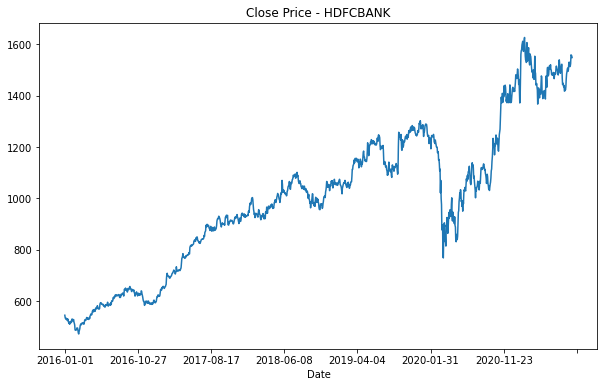

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

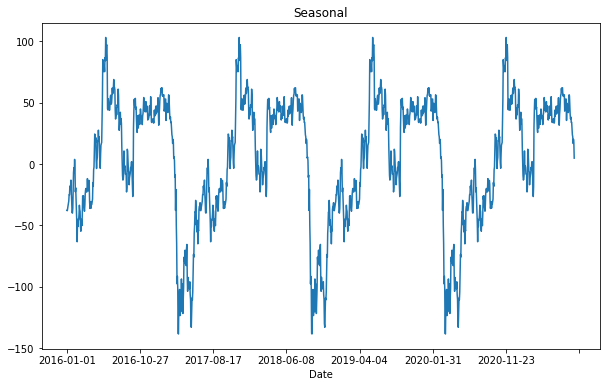

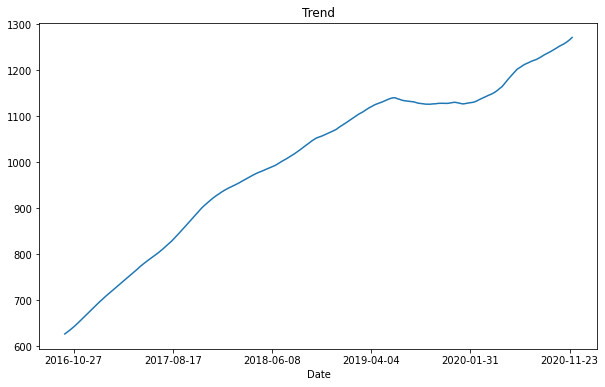

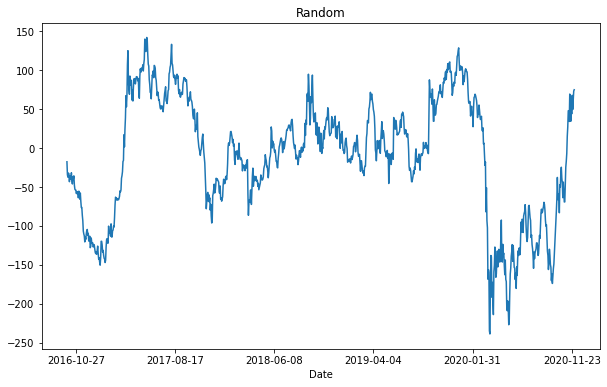

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [ ]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.8159351617116992
3.445221820064572e-12
Test Statistic                -7.934358e+00
p-value                        3.445222e-12
#lags used                     2.000000e+01
number of observations used    1.366000e+03
critical value (1%)           -3.435146e+00
critical value (5%)           -2.863658e+00
critical value (10%)          -2.567898e+00
dtype: float64
Differencing Value :  2


##*ACF*

In [ ]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.00000000e+00  4.14530868e-02 -7.93234340e-02 -4.93681542e-02
  3.16071981e-02  6.29880781e-02 -9.49035456e-02  3.75154390e-02
  4.82657734e-03 -2.76992185e-03 -2.98090515e-03 -3.82526631e-02
  7.74565881e-03  1.55465357e-02 -2.60997521e-02  1.98372568e-02
 -4.10477287e-04  5.25901129e-02 -1.13736502e-02 -1.02195186e-01
 -1.64132404e-02]


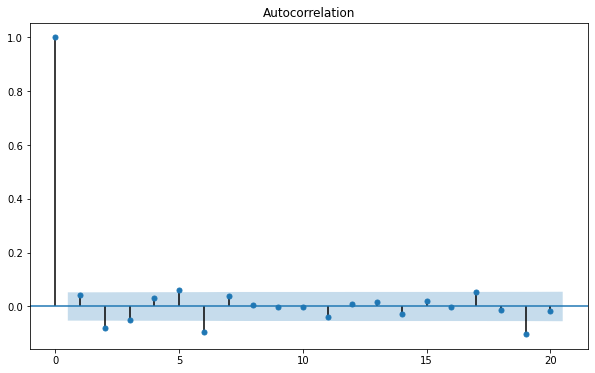

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [ ]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.00000000e+00  4.14829952e-02 -8.12987213e-02 -4.28962723e-02
  2.95188481e-02  5.39176708e-02 -9.89694534e-02  5.91525014e-02
 -9.88200190e-03 -7.92762727e-03  3.35821772e-03 -3.08374714e-02
 -4.89329723e-03  2.11578545e-02 -3.43418302e-02  2.74858472e-02
 -6.39661868e-04  4.72907867e-02 -1.20714937e-02 -9.22606969e-02
 -1.46959739e-02]


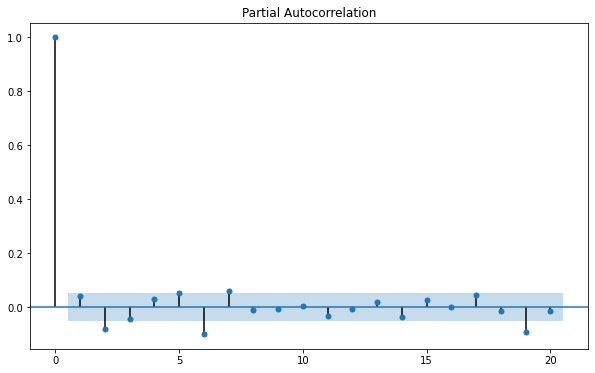

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [ ]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [ ]:
df_stock_train.tail()

Date
2021-07-26    1434.550049
2021-07-27    1439.750000
2021-07-28    1417.300049
2021-07-29    1418.250000
2021-07-30    1426.449951
Name: Close, dtype: float64

In [ ]:
df_stock_test.head()

Date
2021-08-02    1422.650024
2021-08-03    1434.699951
2021-08-04    1465.300049
2021-08-05    1484.849976
2021-08-06    1492.650024
Name: Close, dtype: float64

##*Model Fitting*

In [ ]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [ ]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(2, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

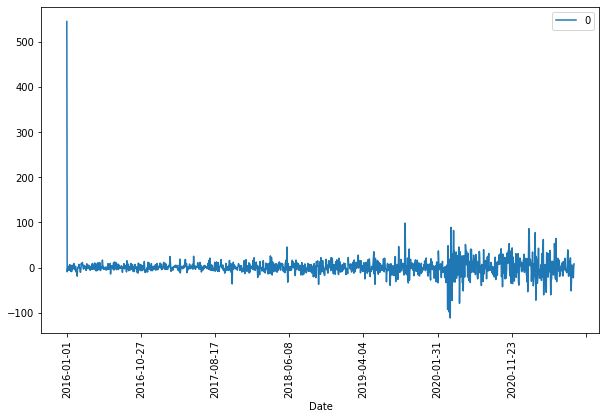

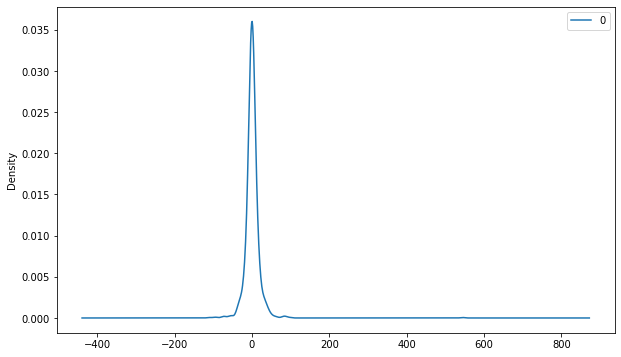

                 0
count  1369.000000
mean      1.041965
std      21.873912
min    -111.299988
25%      -5.950073
50%       0.500000
75%       6.949951
max     544.375000


In [ ]:
model = ARIMA(df_stock_train, order=(0,1,0))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [ ]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 0.9737196792380214


([], <a list of 0 Text major ticklabel objects>)

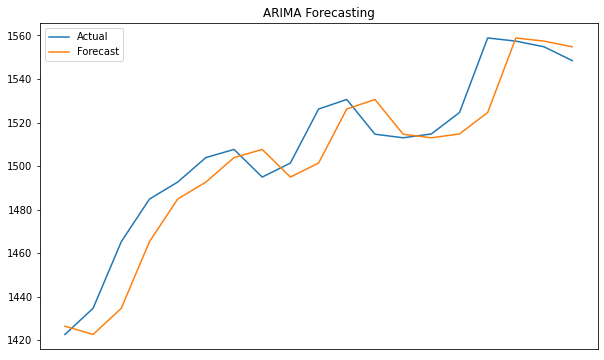

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [ ]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [ ]:
predictions

[1426.449951171875,
 1422.6500244140625,
 1434.699951171875,
 1465.300048828125,
 1484.8499755859375,
 1492.6500244140625,
 1503.9000244140625,
 1507.6500244140625,
 1494.949951171875,
 1501.4000244140625,
 1526.199951171875,
 1530.5999755859375,
 1514.6500244140625,
 1513.0]

#**MARS - Multivariate Adaptive Regression Splines**

In [ ]:
from pyearth import Earth

In [ ]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [ ]:
df_stock_mars_train.shape

(1369, 5)

In [ ]:
df_stock_mars_test.shape

(19, 5)

In [ ]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,541.200012,545.125000,538.075012,544.375000,1597538.0
2016-01-04,542.000000,542.000000,534.049988,535.250000,2593768.0
2016-01-05,535.099976,537.400024,530.674988,531.200012,1580436.0
2016-01-06,528.325012,538.375000,528.325012,533.549988,2082768.0
2016-01-07,530.049988,532.450012,524.849976,528.099976,3027714.0


In [ ]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,1435.000000,1435.000000,1416.250000,1422.650024,6629393.0
2021-08-03,1410.000000,1439.900024,1410.000000,1434.699951,6016560.0
2021-08-04,1441.000000,1474.500000,1440.000000,1465.300049,11026974.0
2021-08-05,1467.099976,1507.050049,1457.400024,1484.849976,9411204.0
2021-08-06,1483.550049,1500.000000,1474.000000,1492.650024,6669635.0
2021-08-09,1492.000000,1507.349976,1476.000000,1503.900024,5499024.0
2021-08-10,1489.000000,1519.750000,1489.000000,1507.650024,7419173.0
2021-08-11,1514.900024,1518.849976,1491.050049,1494.949951,6292893.0
2021-08-12,1497.000000,1507.599976,1489.300049,1501.400024,4298837.0


In [ ]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [ ]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [ ]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 10.41
RMSE/Mean 0.7


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

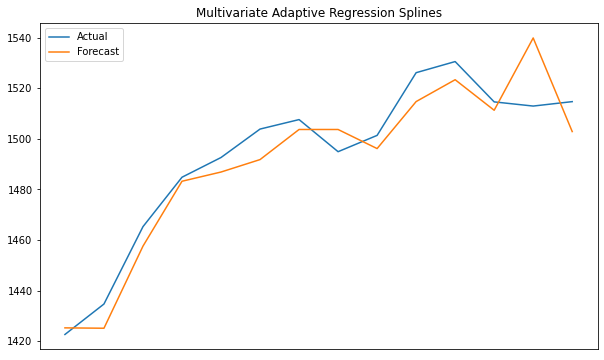

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [ ]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [ ]:
df_stock_var_train.shape

(1369, 4)

In [ ]:
df_stock_var_test.shape

(14, 4)

In [ ]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

##*Granger Causality Test*

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0,0.0000,0.0,0.0
High_y,0.0,1.0000,0.0,0.0
Low_y,0.0,0.0000,1.0,0.0
Close_y,0.0,0.0003,0.0,1.0


##*Cointegration Test*

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  501.34    > 40.1749   =>   True
High   ::  265.75    > 24.2761   =>   True
Low    ::  52.9      > 12.3212   =>   True
Close  ::  2.21      > 4.1296    =>   False


##*ADF Test*

In [ ]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [ ]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.1229
 No. Lags Chosen       = 10
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.7058. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.0897
 No. Lags Chosen       = 2
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.7192. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit ro

##*ADF Test on first order differencing*

In [ ]:
df_differenced = df_stock_var_train.diff().dropna()

In [ ]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -12.1336
 No. Lags Chosen       = 9
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -26.9371
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05

##*Selecting the number of lags*

In [ ]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,19.32,19.33,2.450e+08,19.32
1,17.84,17.92,5.604e+07,17.87
2,17.33,17.47,3.348e+07,17.38
3,17.08,17.28,2.606e+07,17.15
4,17.00,17.26,2.411e+07,17.10
5,16.88,17.21*,2.149e+07,17.00
6,16.83,17.22,2.044e+07,16.98
7,16.77,17.22,1.923e+07,16.94
8,16.73,17.24,1.837e+07,16.92*
9,16.70,17.28,1.796e+07,16.92


##*Fitting the model*

In [ ]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     12:26:29
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    17.8219
Nobs:                     1348.00    HQIC:                   17.0392
Log likelihood:          -18495.5    FPE:                1.57307e+07
AIC:                      16.5705    Det(Omega_mle):     1.24560e+07
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.182272         0.238079            0.766           0.444
L1.Open          -1.117035         0.046577          -23.982           0.000
L1.High           0.152386         0.048603            3.135           0.002


##*Durbin Watson Test*

In [ ]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 2.0
High : 2.0
Low : 2.0
Close : 2.0


##*Getting the Forecast*

In [ ]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

20


array([[-17.        , -12.75      ,  -6.        ,  -6.34997559],
       [  4.94995117,  15.25      ,   7.55004883,  15.04992676],
       [  7.05004883,  35.5       ,  11.44995117,  39.25      ],
       [ 37.        ,   5.34997559,  31.69995117,   4.80004883],
       [ -9.        ,  -7.65002441, -14.25      , -19.05004883],
       [-12.44995117, -21.69995117, -15.94995117, -18.44995117],
       [-10.55004883, -14.        , -13.5       , -15.        ],
       [ -5.90002441,   4.09997559,   0.09997559,  14.84997559],
       [  1.40002441,   1.25      ,   7.        ,  -2.69995117],
       [  7.5       ,  19.40002441,   8.55004883,  21.54992676],
       [ 22.94995117,   3.19995117,  19.15002441,   1.65002441],
       [-40.94995117, -41.09997559, -52.80004883, -51.34997559],
       [-45.        , -34.84997559, -29.84997559, -27.84997559],
       [ 14.09997559,  14.5       ,   8.84997559,   5.54992676],
       [ -4.59997559, -11.05004883,  -9.69995117,  -5.94995117],
       [-21.5       , -13

In [ ]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,3.173819,1.731271,5.543096,-1.623139
2021-08-03,0.021477,-1.338458,-4.838813,-6.251502
2021-08-04,-5.794754,-8.904235,-3.896007,-6.623148
2021-08-05,-10.197306,0.127791,1.013851,6.917977
2021-08-06,18.811148,16.228177,10.019487,8.481833
2021-08-09,2.254340,4.967709,-0.518708,5.468376
2021-08-10,6.690507,-5.543718,5.760790,-5.439956
2021-08-11,-4.688281,-2.322049,-4.181476,-3.268186
2021-08-12,-4.665581,-3.726346,-2.070502,-0.288556


##*Inverting forecast back to original scale*

In [ ]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [ ]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,1422.173819,1433.481271,1413.493047,1424.826812
2021-08-03,1422.195296,1432.142813,1408.654233,1418.575311
2021-08-04,1416.400543,1423.238578,1404.758226,1411.952163
2021-08-05,1406.203237,1423.366369,1405.772077,1418.870140
2021-08-06,1425.014385,1439.594545,1415.791564,1427.351973
2021-08-09,1427.268725,1444.562254,1415.272856,1432.820348
2021-08-10,1433.959233,1439.018536,1421.033646,1427.380393
2021-08-11,1429.270952,1436.696487,1416.852170,1424.112207
2021-08-12,1424.605371,1432.970141,1414.781668,1423.823651


##*Plotting Forecast vs Actual*

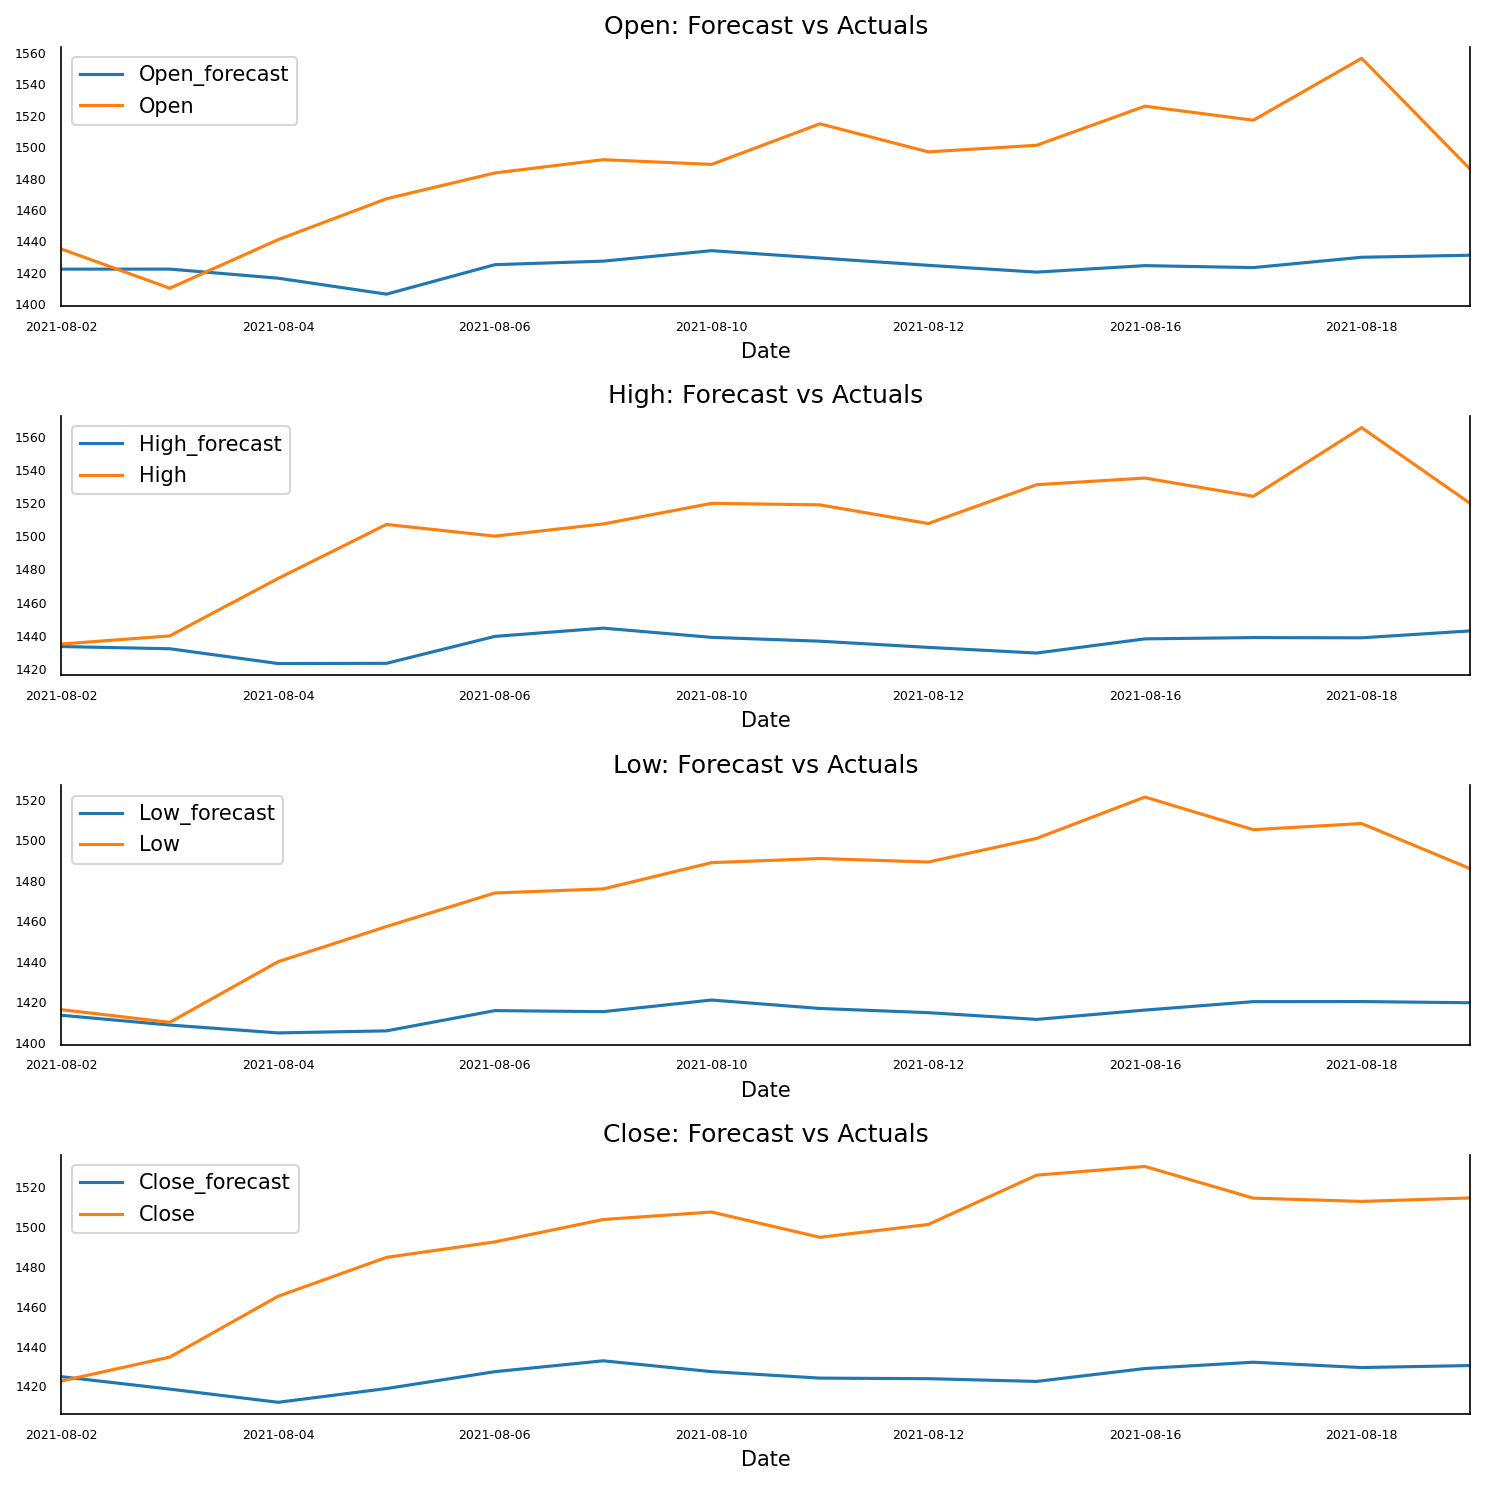

In [ ]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [ ]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  72.0785
rmse_mean :  4.8475

Forecast Accuracy of High
rmse :  77.9133
rmse_mean :  5.1732

Forecast Accuracy of Low
rmse :  68.2429
rmse_mean :  4.6232

Forecast Accuracy of Close
rmse :  73.8067
rmse_mean :  4.9423


#**Linear Regression**

In [ ]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [ ]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.057756,0.057210,0.064725,544.375000,0.006535,4,1,1,0.091661,0.021592
2016-01-04,0.058454,0.054522,0.061208,535.250000,0.011495,0,4,1,0.090919,0.027266
2016-01-05,0.052434,0.050565,0.058259,531.200012,0.006450,1,5,1,0.086044,0.019543
2016-01-06,0.046523,0.051403,0.056206,533.549988,0.008951,2,6,1,0.066755,0.040504
2016-01-07,0.048028,0.046306,0.053170,528.099976,0.013656,3,7,1,0.070447,0.025059


In [ ]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.837550,0.822777,0.832059,1422.650024,0.031588,0,2,8,1.023069,0.095351
2021-08-03,0.815739,0.826992,0.826598,1434.699951,0.028537,1,3,8,1.037370,0.165642
2021-08-04,0.842785,0.856759,0.852811,1465.300049,0.053484,2,4,8,1.041369,0.194642
2021-08-05,0.865556,0.884762,0.868015,1484.849976,0.045439,3,5,8,1.035070,0.290150
2021-08-06,0.879908,0.878697,0.882520,1492.650024,0.031789,4,6,8,1.037309,0.141056


##*Checking for multicollinearity*

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [ ]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [ ]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [ ]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [ ]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [ ]:
print(model.summary2())

                  Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.941     
Dependent Variable:  Close            AIC:                15451.3133
Date:                2021-09-15 12:26 BIC:                15508.7535
No. Observations:    1369             Log-Likelihood:     -7714.7   
Df Model:            10               F-statistic:        2195.     
Df Residuals:        1358             Prob (F-statistic): 0.00      
R-squared:           0.942            Scale:              4631.7    
--------------------------------------------------------------------
                Coef.   Std.Err.    t     P>|t|    [0.025    0.975] 
--------------------------------------------------------------------
Volume         296.7081  57.7888   5.1344 0.0000  183.3431  410.0730
NIFTY50       1142.4139   8.7652 130.3347 0.0000 1125.2191 1159.6088
Range          276.3937  25.7251  10.7441 0.0000  225.9284  326.8589
Day of Week_0  468.6971   5.5476  84.4861 0.0000  457

In [ ]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


Volume
NIFTY50
Range
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Month_10
Month_11
Month_12


In [ ]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
15.247385602020339
